In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [19]:
class BatsmanState(TypedDict):
    runs_scored: int
    balls_faced: int
    number_of_fours: int
    number_of_sixes: int

    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float
    summary: str

In [20]:
def calculate_strike_rate(state: BatsmanState) -> float:
    if state['balls_faced'] == 0:
        return 0.0
    strike_rate = (state['runs_scored'] / state['balls_faced']) * 100
    return {'strike_rate': strike_rate}

In [21]:
def calculate_balls_per_boundary(state: BatsmanState) -> float:
    total_boundaries = state['number_of_fours'] + state['number_of_sixes']
    if total_boundaries == 0:
        balls_per_boundary = float('inf')  # No boundaries, infinite balls per boundary
    balls_per_boundary = state['balls_faced'] / total_boundaries
    return {'balls_per_boundary': balls_per_boundary}

In [22]:
def calculate_boundary_percentage(state: BatsmanState) -> float:
    if state['runs_scored'] == 0:
        boundary_percentage = 0.0
    total_boundaries = state['number_of_fours'] + state['number_of_sixes']
    boundary_percentage = (total_boundaries / state['runs_scored']) * 100
    return {'boundary_percentage': boundary_percentage}

In [23]:
def generate_summary(state: BatsmanState) -> str:
    summary = f"Batsman Summary: {state['runs_scored']} runs from {state['balls_faced']} balls, strike rate: {state['strike_rate']:.2f}"
    return {'summary': summary}

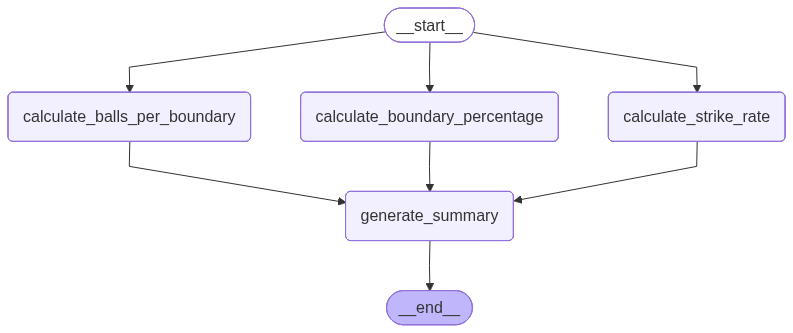

In [24]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_balls_per_boundary', calculate_balls_per_boundary)
graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage)
graph.add_node('generate_summary', generate_summary)

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_balls_per_boundary')
graph.add_edge(START, 'calculate_boundary_percentage')
graph.add_edge('calculate_strike_rate', 'generate_summary')
graph.add_edge('calculate_balls_per_boundary', 'generate_summary')
graph.add_edge('calculate_boundary_percentage', 'generate_summary')
graph.add_edge('generate_summary', END)

workflow = graph.compile()
workflow

In [25]:
initial_state = {
    "runs_scored": 100,
    "balls_faced": 50,
    "number_of_fours": 10,
    "number_of_sixes": 5
}

workflow.invoke(initial_state)

{'runs_scored': 100,
 'balls_faced': 50,
 'number_of_fours': 10,
 'number_of_sixes': 5,
 'strike_rate': 200.0,
 'balls_per_boundary': 3.3333333333333335,
 'boundary_percentage': 15.0,
 'summary': 'Batsman Summary: 100 runs from 50 balls, strike rate: 200.00'}